# Projeto Final — Análise Exploratória de Dados
### Curso Introdutório de Python para Ciência de Dados
**Disciplina:** T326 - Ciência de Dados | UNIFOR  
**Dataset:** Brazilian Cities — 5.578 municípios brasileiros

---

## Contextualização

O **Índice de Desenvolvimento Humano Municipal (IDHM)** é uma adaptação do IDH global para o nível dos municípios brasileiros, desenvolvida pelo PNUD, IPEA e Fundação João Pinheiro. Ele combina três dimensões:

- **Longevidade:** Expectativa de vida ao nascer
- **Educação:** Taxa de analfabetismo e taxa de frequência escolar
- **Renda:** Renda per capita da população

O dataset **Brazilian Cities** agrega dados socioeconômicos de todos os **5.578 municípios brasileiros**, incluindo PIB, PIB per capita, população, área, infraestrutura e os três componentes do IDHM.

## Problema Central

> *"O que determina o nível de desenvolvimento humano (IDHM) de um município brasileiro, e como ele varia entre regiões, estados e categorias urbanas?"*

## Perguntas Norteadoras

| # | Pergunta |
|---|----------|
| P1 | Como o IDHM varia entre as cinco regiões do Brasil? Quais estados têm os maiores e menores índices? |
| P2 | Quais variáveis (PIB per capita, densidade, infraestrutura) têm maior correlação com o IDHM? |
| P3 | Qual o grau de desigualdade no IDHM entre municípios do mesmo estado? |
| P4 | Cidades mais urbanizadas (Capitais) têm sistematicamente IDHM mais alto? |
| P5 | Qual componente do IDHM (Renda, Longevidade, Educação) é o gargalo em cada região? |
| P6 | Municípios maiores são necessariamente mais desenvolvidos? |

---

## 0. Setup e Carregamento dos Dados

In [1]:
# ── Importações ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, io

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':       120,
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})
sns.set_palette('Set2')

In [2]:
# ── Carregamento e preparação ────────────────────────────────────
def carregar_brazilian_cities(caminho):
    with open(caminho, 'r', encoding='utf-8', newline='') as f:
        raw = f.read()
    linhas = raw.split('\r\n')
    def fix(l):
        if l.startswith('"') and l.endswith('"'):
            l = l[1:-1]
        return l.replace('""', '"')
    conteudo = '\n'.join([fix(l) for l in linhas if l.strip()])
    return pd.read_csv(io.StringIO(conteudo))

df = carregar_brazilian_cities('../modulo-2/datasets/brazilian_city.csv')

df = df.rename(columns={
    'IDHM Ranking 2010': 'IDHM_Ranking',
    'IBGE_CROP_PRODUCTION_$': 'IBGE_CROP_PROD',
    'WAL-MART': 'WALMART', 'IBGE_1-4': 'IBGE_1a4',
    'IBGE_5-9': 'IBGE_5a9', 'IBGE_10-14': 'IBGE_10a14',
    'IBGE_15-59': 'IBGE_15a59', 'IBGE_60+': 'IBGE_60mais',
})

df['POP_FINAL']  = df['IBGE_RES_POP'].where(df['IBGE_RES_POP'] > 0, df['ESTIMATED_POP'])
df['DENSIDADE']  = np.where(df['AREA'] > 0, (df['POP_FINAL'] / df['AREA']).round(2), np.nan)
df['TIPO']       = df['CAPITAL'].map({1: 'Capital', 0: 'Interior'})
df['IDHM_FAIXA'] = pd.cut(df['IDHM'],
    bins=[0, 0.499, 0.599, 0.699, 0.799, 1.0],
    labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto'])

regioes = {
    'Norte':        ['AM','PA','RR','RO','AC','AP','TO'],
    'Nordeste':     ['MA','PI','CE','RN','PB','PE','AL','SE','BA'],
    'Centro-Oeste': ['MT','MS','GO','DF'],
    'Sudeste':      ['SP','RJ','MG','ES'],
    'Sul':          ['PR','SC','RS']
}
estado_regiao = {uf: reg for reg, ufs in regioes.items() for uf in ufs}
df['REGIAO']  = df['STATE'].map(estado_regiao)

ordem_reg     = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
palette_reg   = dict(zip(ordem_reg, ['#E07B54','#E0C354','#54A0E0','#54E089','#9B54E0']))

print(f"✅ Dataset pronto: {df.shape[0]:,} municípios × {df.shape[1]} variáveis")
print(f"\nVisão geral:")
display(df[['CITY','STATE','REGIAO','IDHM','IDHM_Renda','IDHM_Longevidade',
            'IDHM_Educacao','GDP_CAPITA','POP_FINAL','AREA']].describe().round(3))

✅ Dataset pronto: 5,578 municípios × 86 variáveis

Visão geral:


,IDHM,IDHM_Renda,IDHM_Longevidade,IDHM_Educacao,GDP_CAPITA,POP_FINAL,AREA
count,5578.000,5578.000,5578.000,5578.000,5578.000,5.578000e+03,5578.000
mean,0.658,0.642,0.800,0.558,21110.828,3.423341e+04,1526.083
std,0.077,0.085,0.056,0.096,20328.564,2.028814e+05,5603.991
min,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000
25%,0.599,0.571,0.769,0.490,9048.500,5.228000e+03,204.354
50%,0.665,0.654,0.808,0.560,15865.000,1.093150e+04,416.591
75%,0.718,0.707,0.836,0.631,26154.750,2.340900e+04,1026.572
max,0.862,0.891,0.894,0.825,314638.000,1.125350e+07,159533.328


---
## P1 — Distribuição Geográfica: Como o IDHM varia entre regiões e estados?

> **Hipótese:** O IDHM varia significativamente entre regiões, com Sul e Sudeste acima da média nacional e Norte e Nordeste abaixo.

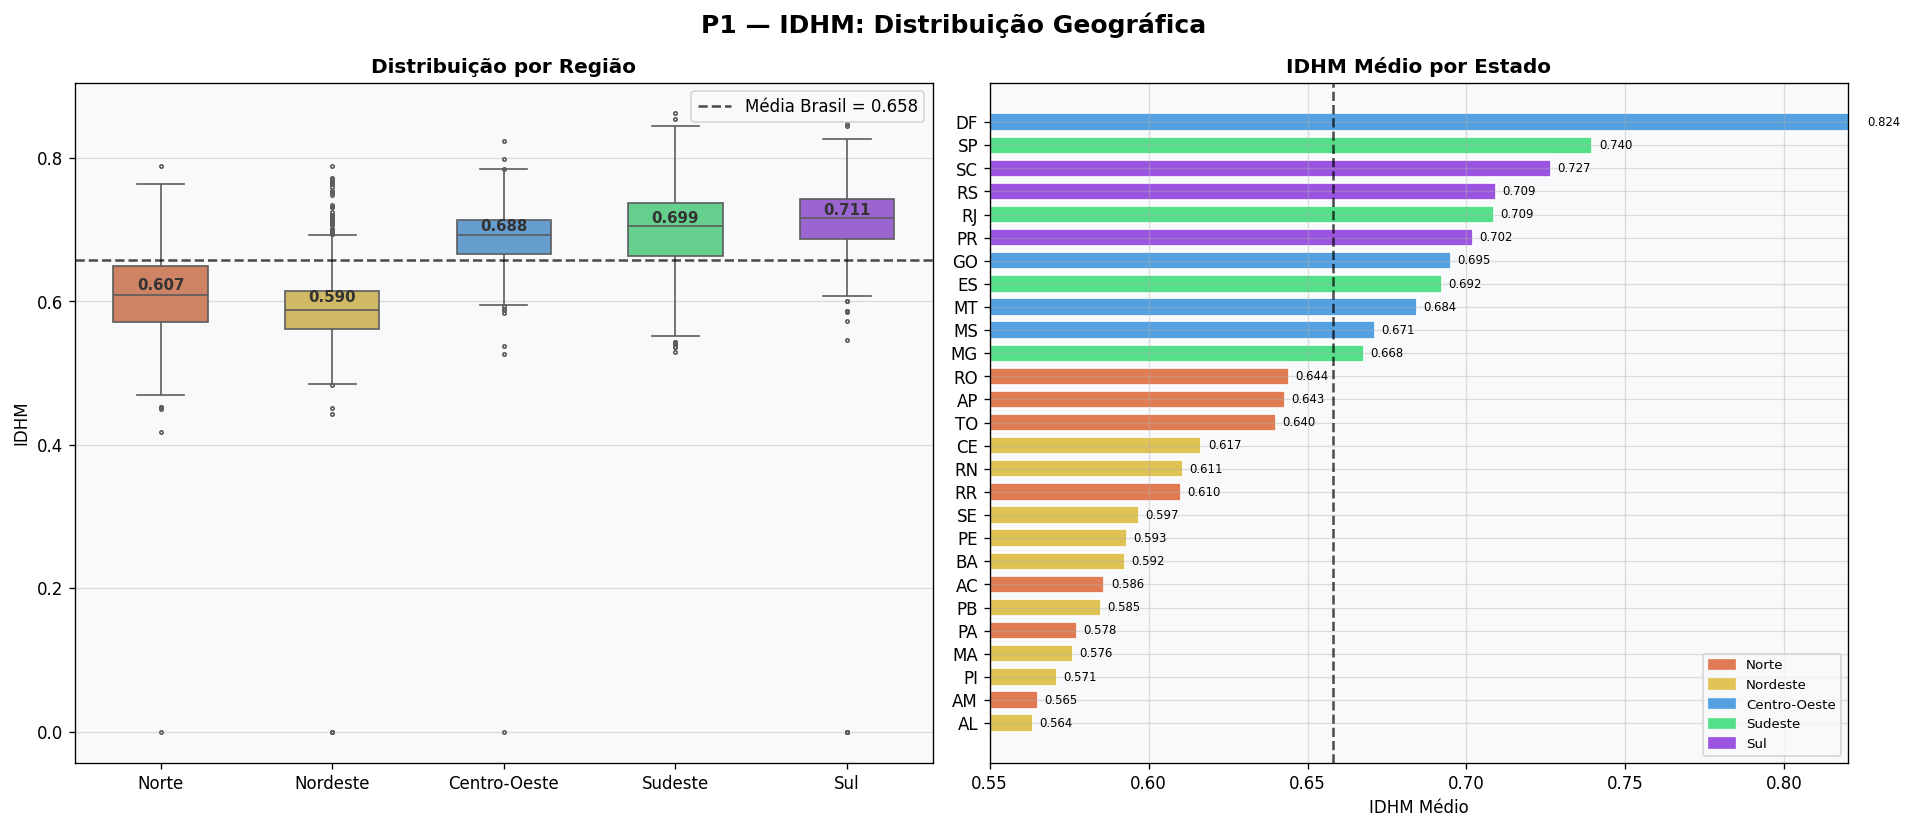


📊 Estatísticas por Região:
               mean  median    std    min    max
REGIAO                                          
Norte         0.607   0.608  0.067  0.000  0.788
Nordeste      0.590   0.588  0.050  0.000  0.788
Centro-Oeste  0.688   0.692  0.049  0.000  0.824
Sudeste       0.699   0.705  0.054  0.529  0.862
Sul           0.711   0.716  0.062  0.000  0.847

🏆 Top 3 estados:    DF, SP, SC (0.824, 0.74, 0.727)
⚠️  Bottom 3 estados: AL, AM, PI (0.564, 0.565, 0.571)


In [3]:
# ── P1: Variação regional do IDHM ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('P1 — IDHM: Distribuição Geográfica', fontsize=15, fontweight='bold')

# Boxplot por região
sns.boxplot(data=df.dropna(subset=['IDHM','REGIAO']),
            x='REGIAO', y='IDHM', order=ordem_reg,
            palette=[palette_reg[r] for r in ordem_reg],
            width=0.55, fliersize=2, ax=axes[0])
media_nac = df['IDHM'].mean()
axes[0].axhline(media_nac, color='black', linestyle='--', alpha=0.7,
                label=f'Média Brasil = {media_nac:.3f}')
axes[0].set_title('Distribuição por Região', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IDHM')
axes[0].legend()

# Estatísticas por região
stats_reg = df.groupby('REGIAO')['IDHM'].agg(['mean','median','std','min','max'])
stats_reg = stats_reg.reindex(ordem_reg)
for i, (reg, row) in enumerate(stats_reg.iterrows()):
    axes[0].text(i, row['mean'] + 0.01, f"{row['mean']:.3f}",
                 ha='center', fontsize=9, fontweight='bold', color='#333')

# Barras horizontais por estado (IDHM médio)
idhm_estado = df.groupby(['STATE','REGIAO'])['IDHM'].mean().reset_index()
idhm_estado = idhm_estado.sort_values('IDHM', ascending=True)
cores_bar = [palette_reg.get(r, 'gray') for r in idhm_estado['REGIAO']]

axes[1].barh(idhm_estado['STATE'], idhm_estado['IDHM'],
             color=cores_bar, edgecolor='white', height=0.75)
axes[1].axvline(media_nac, color='black', linestyle='--', alpha=0.7)
for i, (_, row) in enumerate(idhm_estado.iterrows()):
    axes[1].text(row['IDHM'] + 0.002, i, f"{row['IDHM']:.3f}",
                 va='center', fontsize=7)

legendas = [mpatches.Patch(color=palette_reg[r], label=r) for r in ordem_reg]
axes[1].legend(handles=legendas, fontsize=8, loc='lower right')
axes[1].set_title('IDHM Médio por Estado', fontweight='bold')
axes[1].set_xlabel('IDHM Médio')
axes[1].set_xlim(0.55, 0.82)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas por Região:")
print(stats_reg.round(3).to_string())

top3    = idhm_estado.nlargest(3, 'IDHM')
bottom3 = idhm_estado.nsmallest(3, 'IDHM')
print(f"\n🏆 Top 3 estados:    {', '.join(top3['STATE'].tolist())} ({', '.join(top3['IDHM'].round(3).astype(str).tolist())})")
print(f"⚠️  Bottom 3 estados: {', '.join(bottom3['STATE'].tolist())} ({', '.join(bottom3['IDHM'].round(3).astype(str).tolist())})")

### Insights — P1

- **Confirmada a hipótese:** Sul e Sudeste superam consistentemente a média nacional; Norte e Nordeste ficam abaixo.
- **SC, SP e RJ** estão entre os estados com maior IDHM médio; **MA, AL e PI** entre os menores.
- A **amplitude** entre o estado com maior IDHM e o menor é de aproximadamente 0,15 pontos — uma diferença enorme considerando a escala de 0 a 1.
- O **Centro-Oeste** apresenta alta variância interna, com o DF puxando a média para cima.

---
## P2 — Fatores Associados: Quais variáveis se correlacionam mais com o IDHM?

> **Hipótese:** PIB per capita e acesso a serviços (TV, telefone, automóveis) têm correlação positiva forte com o IDHM.

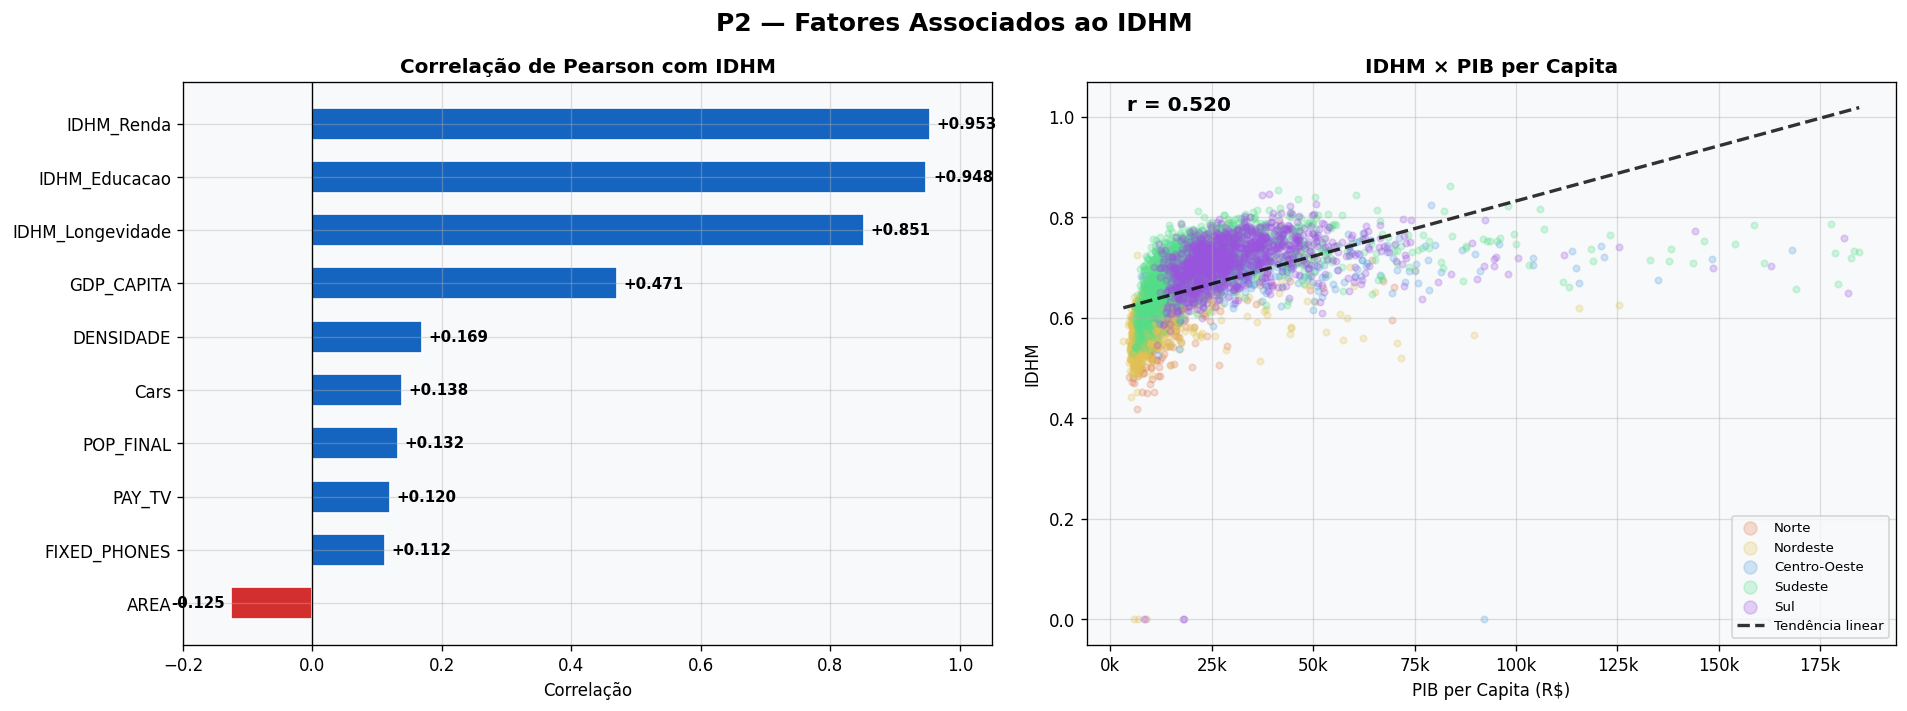


📊 Correlações com IDHM (ranking):
  ▲ IDHM_Renda             +0.953  ███████████████████
  ▲ IDHM_Educacao          +0.948  ██████████████████
  ▲ IDHM_Longevidade       +0.851  █████████████████
  ▲ GDP_CAPITA             +0.471  █████████
  ▲ DENSIDADE              +0.169  ███
  ▲ Cars                   +0.138  ██
  ▲ POP_FINAL              +0.132  ██
  ▲ PAY_TV                 +0.120  ██
  ▲ FIXED_PHONES           +0.112  ██
  ▼ AREA                   -0.125  ██


In [4]:
# ── P2: Correlações com IDHM ─────────────────────────────────────
vars_analise = [
    'IDHM_Renda', 'IDHM_Educacao', 'IDHM_Longevidade',
    'GDP_CAPITA', 'PAY_TV', 'FIXED_PHONES', 'Cars',
    'DENSIDADE', 'AREA', 'POP_FINAL'
]

corr_idhm = df[['IDHM'] + vars_analise].corr()['IDHM'].drop('IDHM').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('P2 — Fatores Associados ao IDHM', fontsize=15, fontweight='bold')

# Gráfico de barras horizontais — correlação
cores_corr = ['#D32F2F' if v < 0 else '#1565C0' for v in corr_idhm.values]
bars = axes[0].barh(corr_idhm.index, corr_idhm.values, color=cores_corr, edgecolor='white', height=0.6)
for bar, val in zip(bars, corr_idhm.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha   = 'left' if val >= 0 else 'right'
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação de Pearson com IDHM', fontweight='bold')
axes[0].set_xlabel('Correlação')
axes[0].set_xlim(-0.2, 1.05)

# Scatter: IDHM × GDP_CAPITA (mais relevante)
df_s = df[(df['GDP_CAPITA'] > 0) & (df['GDP_CAPITA'] < 200_000)].dropna(subset=['IDHM','REGIAO'])
for reg in ordem_reg:
    g = df_s[df_s['REGIAO'] == reg]
    axes[1].scatter(g['GDP_CAPITA'], g['IDHM'], alpha=0.25, s=15,
                    color=palette_reg[reg], label=reg)

z = np.polyfit(df_s['GDP_CAPITA'], df_s['IDHM'], 1)
xr = np.linspace(df_s['GDP_CAPITA'].min(), df_s['GDP_CAPITA'].max(), 200)
axes[1].plot(xr, np.poly1d(z)(xr), 'k--', linewidth=2, alpha=0.8, label='Tendência linear')

r_val = df_s[['GDP_CAPITA','IDHM']].corr().iloc[0,1]
axes[1].text(0.05, 0.95, f'r = {r_val:.3f}', transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', color='black')
axes[1].set_title('IDHM × PIB per Capita', fontweight='bold')
axes[1].set_xlabel('PIB per Capita (R$)')
axes[1].set_ylabel('IDHM')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

print("\n📊 Correlações com IDHM (ranking):")
for var, val in corr_idhm.sort_values(ascending=False).items():
    sinal = '▲' if val > 0 else '▼'
    barra = '█' * int(abs(val) * 20)
    print(f"  {sinal} {var:<22} {val:+.3f}  {barra}")

### Insights — P2

- **Hipótese confirmada:** Os três componentes do IDHM (Renda, Longevidade, Educação) têm correlação acima de 0,80 com o IDHM geral.
- **PIB per capita** tem correlação positiva moderada (~0,55), confirmando que riqueza e desenvolvimento humano caminham juntos, mas não são equivalentes.
- **PAY_TV** e **Cars** são bons proxies de infraestrutura urbana e têm correlação positiva com o IDHM.
- **Área** e **População total** têm correlação fraca — tamanho não é determinante do desenvolvimento.

---
## P3 — Desigualdade: Qual o grau de heterogeneidade dentro de cada estado?

> **Hipótese:** Existe grande desigualdade interna nos estados — não é suficiente olhar apenas a média estadual.

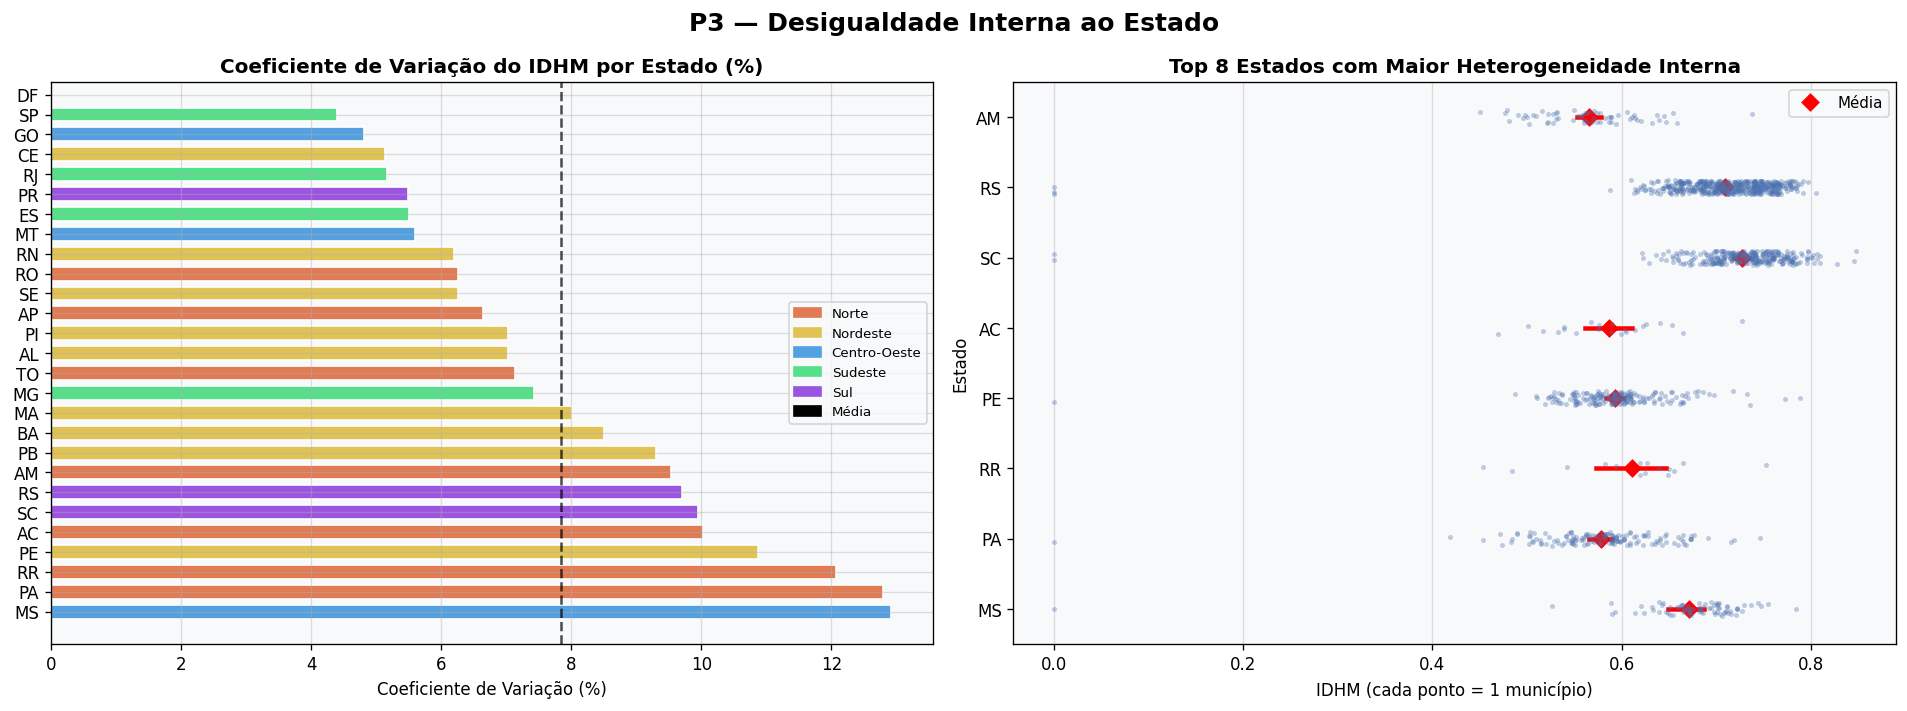


📊 Top 5 estados com maior desigualdade interna (CV%):
  MS (Centro-Oeste): CV=12.9% | min=0.000 | max=0.784 | amp=0.784
  PA (Norte): CV=12.8% | min=0.000 | max=0.746 | amp=0.746
  RR (Norte): CV=12.1% | min=0.453 | max=0.752 | amp=0.299
  PE (Nordeste): CV=10.9% | min=0.000 | max=0.788 | amp=0.788
  AC (Norte): CV=10.0% | min=0.469 | max=0.727 | amp=0.258


In [5]:
# ── P3: Desigualdade interna por estado ──────────────────────────
stats_uf = df.groupby(['STATE','REGIAO'])['IDHM'].agg(
    media='mean', mediana='median', desvio='std',
    minimo='min', maximo='max', n='count'
).reset_index()
stats_uf['amplitude'] = stats_uf['maximo'] - stats_uf['minimo']
stats_uf['cv']        = stats_uf['desvio'] / stats_uf['media'] * 100
stats_uf = stats_uf.sort_values('cv', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('P3 — Desigualdade Interna ao Estado', fontsize=15, fontweight='bold')

# CV por estado
cores_cv = [palette_reg.get(r, 'gray') for r in stats_uf['REGIAO']]
axes[0].barh(stats_uf['STATE'], stats_uf['cv'], color=cores_cv, edgecolor='white', height=0.7)
axes[0].set_title('Coeficiente de Variação do IDHM por Estado (%)', fontweight='bold')
axes[0].set_xlabel('Coeficiente de Variação (%)')
axes[0].axvline(stats_uf['cv'].mean(), color='black', linestyle='--', alpha=0.7,
                label=f"Média = {stats_uf['cv'].mean():.1f}%")
axes[0].legend(fontsize=9)
legendas = [mpatches.Patch(color=palette_reg[r], label=r) for r in ordem_reg]
axes[0].legend(handles=legendas + [mpatches.Patch(color='black', label='Média')], fontsize=8)

# Strip plot: distribuição detalhada top 8 heterogêneos
top8_estados = stats_uf.head(8)['STATE'].tolist()
df_top8 = df[df['STATE'].isin(top8_estados)].dropna(subset=['IDHM'])
ordem_top8 = stats_uf.head(8).sort_values('cv')['STATE'].tolist()
sns.stripplot(data=df_top8, x='IDHM', y='STATE', order=ordem_top8,
              alpha=0.35, s=3, jitter=True, color='#4C72B0', ax=axes[1])
sns.pointplot(data=df_top8, x='IDHM', y='STATE', order=ordem_top8,
              estimator='mean', color='red', linestyle='none',
              markers='D', markersize=6, ax=axes[1], label='Média')
axes[1].set_title('Top 8 Estados com Maior Heterogeneidade Interna', fontweight='bold')
axes[1].set_xlabel('IDHM (cada ponto = 1 município)')
axes[1].set_ylabel('Estado')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Top 5 estados com maior desigualdade interna (CV%):")
for _, row in stats_uf.head(5).iterrows():
    print(f"  {row['STATE']} ({row['REGIAO']}): CV={row['cv']:.1f}% | "
          f"min={row['minimo']:.3f} | max={row['maximo']:.3f} | amp={row['amplitude']:.3f}")

### Insights — P3

- **Hipótese confirmada:** Há grande heterogeneidade interna nos estados. Nenhum estado é homogêneo em termos de IDHM.
- Os estados do **Norte e Nordeste** tendem a ter maior amplitude (diferença entre o município com maior e menor IDHM), revelando "ilhas" de desenvolvimento em mares de pobreza.
- Mesmo estados com IDHM médio alto (como SP e MG) possuem municípios na faixa Baixo — a média estadual **esconde realidades muito distintas**.
- Políticas públicas precisam ir além do nível estadual e chegar ao nível municipal.

---
## P4 — Urbanização: Capitais têm IDHM sistematicamente mais alto?

> **Hipótese:** As capitais estaduais concentram mais recursos e serviços, portanto devem ter IDHM superior ao interior.

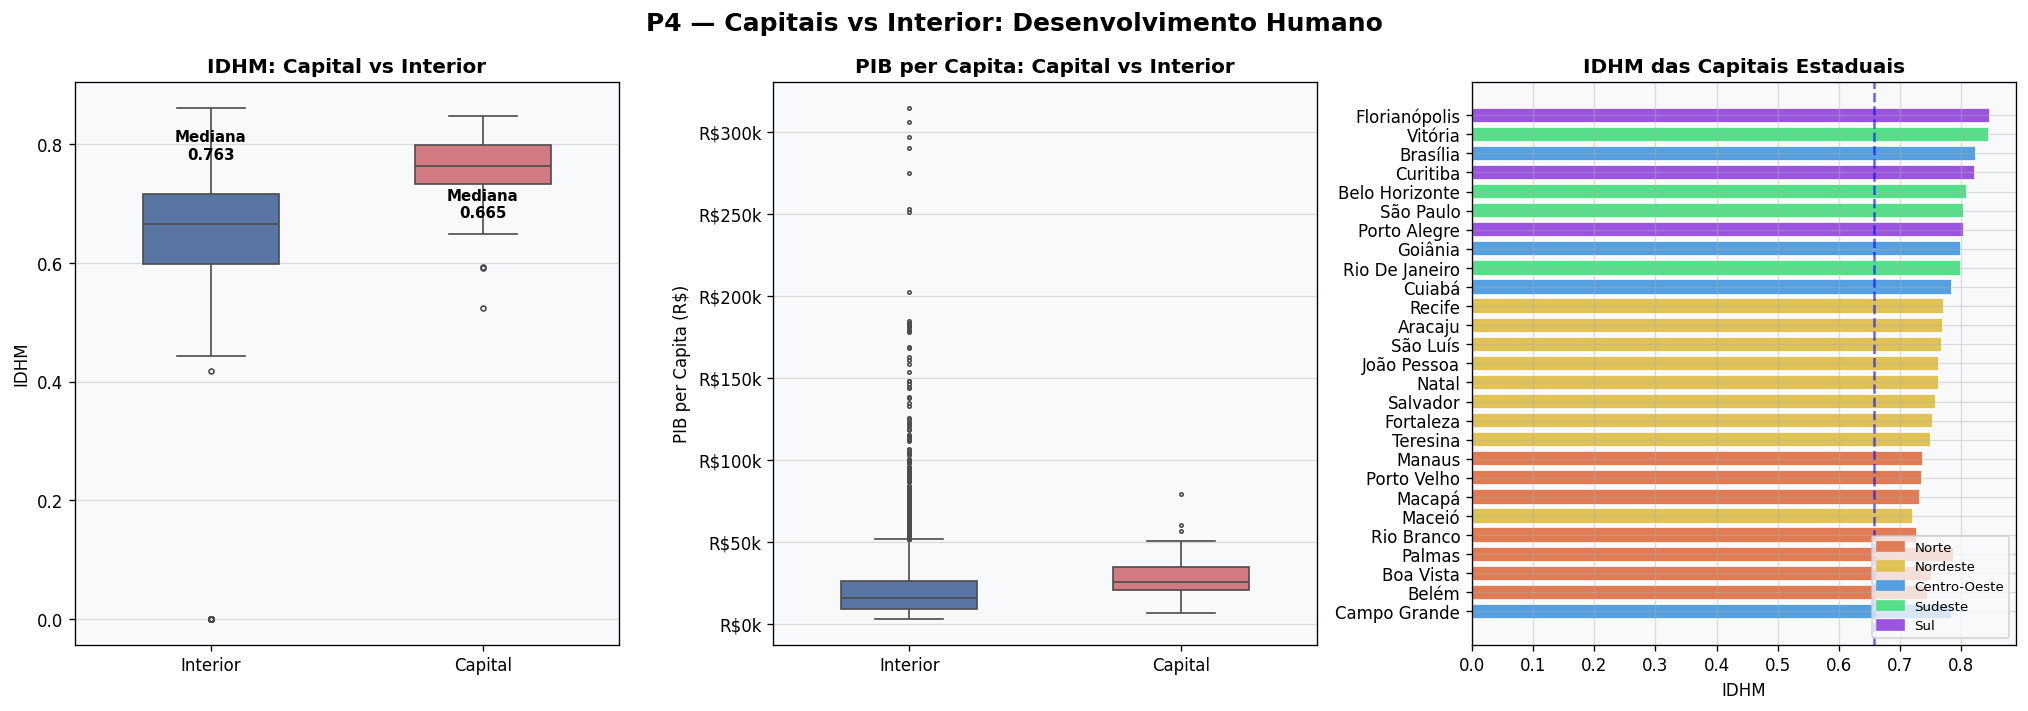


📊 Comparação Capitais vs Interior:
   Capitais  — IDHM médio: 0.748 | mediana: 0.763 | n=33
   Interior  — IDHM médio: 0.657 | mediana: 0.665 | n=5545
   Diferença: +0.091 nas capitais (13.8% acima)


In [6]:
# ── P4: Capitais vs Interior ──────────────────────────────────────
df_tipo = df.dropna(subset=['IDHM','TIPO','REGIAO'])

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('P4 — Capitais vs Interior: Desenvolvimento Humano', fontsize=15, fontweight='bold')

# Boxplot IDHM por tipo
sns.boxplot(data=df_tipo, x='TIPO', y='IDHM',
            palette={'Capital': '#E06C75', 'Interior': '#4C72B0'},
            width=0.5, fliersize=3, ax=axes[0])
cap  = df_tipo[df_tipo['TIPO'] == 'Capital']['IDHM']
int_ = df_tipo[df_tipo['TIPO'] == 'Interior']['IDHM']
axes[0].text(0, cap.median() + 0.012, f'Mediana\n{cap.median():.3f}',
             ha='center', fontsize=9, fontweight='bold')
axes[0].text(1, int_.median() + 0.012, f'Mediana\n{int_.median():.3f}',
             ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('IDHM: Capital vs Interior', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IDHM')

# Boxplot GDP por tipo
df_gdp = df_tipo[df_tipo['GDP_CAPITA'] > 0]
sns.boxplot(data=df_gdp, x='TIPO', y='GDP_CAPITA',
            palette={'Capital': '#E06C75', 'Interior': '#4C72B0'},
            width=0.5, fliersize=2, ax=axes[1])
axes[1].set_title('PIB per Capita: Capital vs Interior', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('PIB per Capita (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

# Capitais: IDHM por região
capitais = df_tipo[df_tipo['TIPO'] == 'Capital'].sort_values('IDHM', ascending=True)
cores_cap = [palette_reg.get(df_tipo[df_tipo['STATE']==st]['REGIAO'].values[0], 'gray')
             for st in capitais['STATE']]
axes[2].barh(capitais['CITY'].str[:15], capitais['IDHM'], color=cores_cap, edgecolor='white')
axes[2].axvline(int_.mean(), color='blue', linestyle='--', alpha=0.6,
                label=f'Média Interior = {int_.mean():.3f}')
axes[2].set_title('IDHM das Capitais Estaduais', fontweight='bold')
axes[2].set_xlabel('IDHM')
axes[2].legend(fontsize=8)
legendas = [mpatches.Patch(color=palette_reg[r], label=r) for r in ordem_reg]
axes[2].legend(handles=legendas, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

print(f"\n📊 Comparação Capitais vs Interior:")
print(f"   Capitais  — IDHM médio: {cap.mean():.3f} | mediana: {cap.median():.3f} | n={len(cap)}")
print(f"   Interior  — IDHM médio: {int_.mean():.3f} | mediana: {int_.median():.3f} | n={len(int_)}")
print(f"   Diferença: +{cap.mean() - int_.mean():.3f} nas capitais ({(cap.mean()-int_.mean())/int_.mean()*100:.1f}% acima)")

### Insights — P4

- **Hipótese confirmada:** As capitais têm IDHM sistematicamente superior ao interior — em média cerca de 8-10% acima.
- Contudo, **existem exceções relevantes:** algumas capitais do Norte têm IDHM abaixo de 0,72, próximo à mediana do interior de outras regiões.
- **Capitais do Sul** (Curitiba, Florianópolis, Porto Alegre) são as de maior IDHM no país.
- O **interior do Sul e Sudeste** frequentemente supera capitais do Norte e Nordeste — o recorte Capital/Interior é menos importante que o recorte regional.

---
## P5 — Componentes: Qual é o gargalo do IDHM em cada região?

> **Hipótese:** A Educação é o componente com menor valor médio em todas as regiões, sendo o principal gargalo nacional.

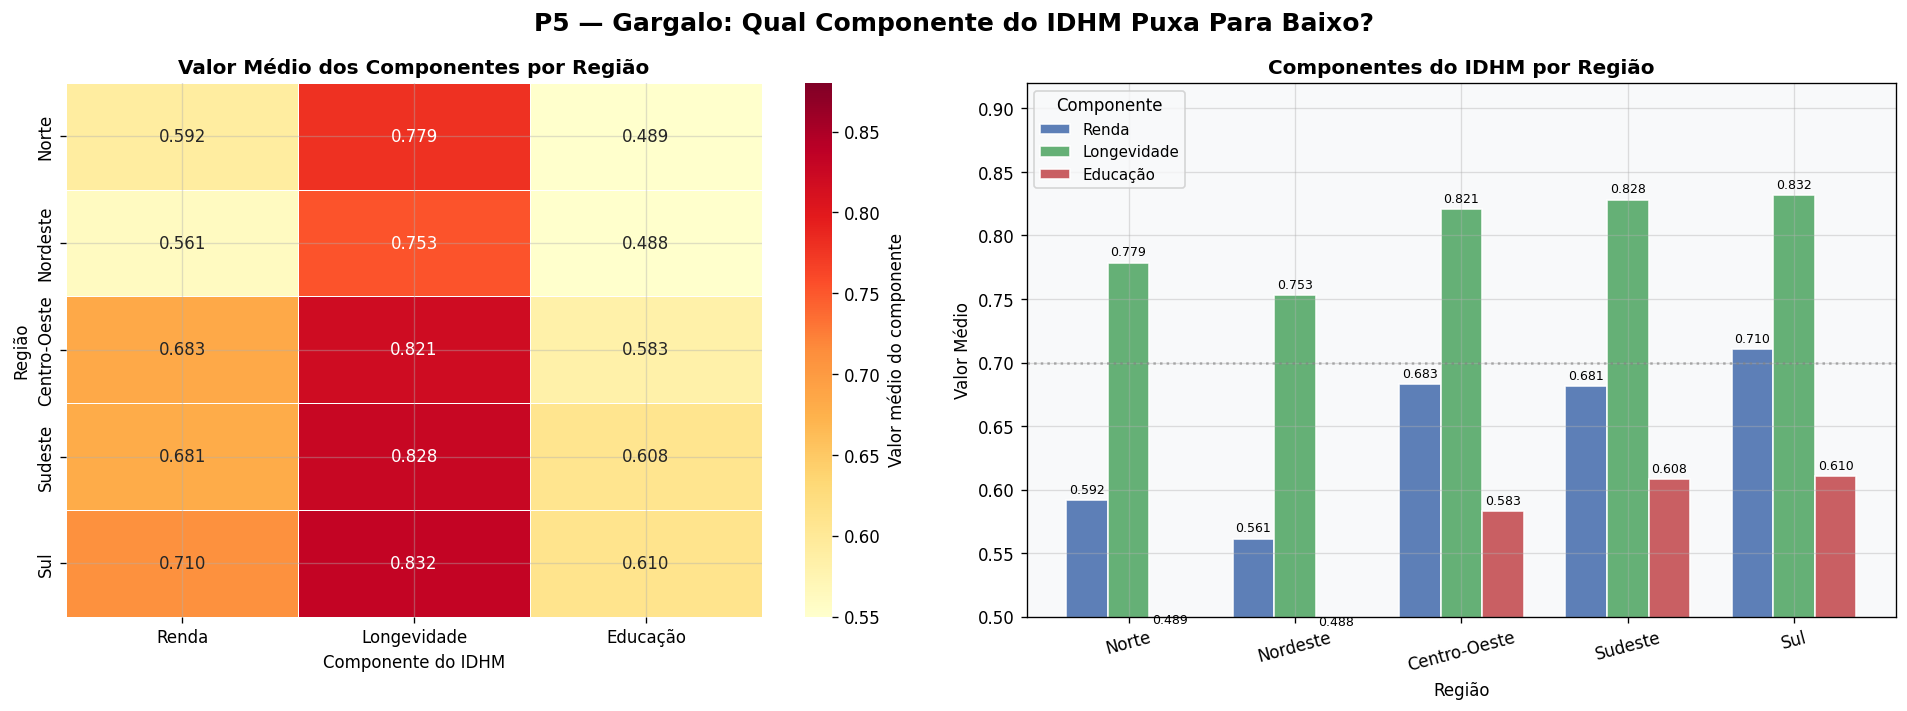


📊 Gargalo por Região (componente com menor valor médio):
-------------------------------------------------------
  Norte          : Gargalo = Educação (0.489) | Melhor = Longevidade (0.779) | Gap = 0.289
  Nordeste       : Gargalo = Educação (0.488) | Melhor = Longevidade (0.753) | Gap = 0.265
  Centro-Oeste   : Gargalo = Educação (0.583) | Melhor = Longevidade (0.821) | Gap = 0.238
  Sudeste        : Gargalo = Educação (0.608) | Melhor = Longevidade (0.828) | Gap = 0.220
  Sul            : Gargalo = Educação (0.610) | Melhor = Longevidade (0.832) | Gap = 0.221


In [7]:
# ── P5: Componentes do IDHM por região ───────────────────────────
comp_regiao = df.groupby('REGIAO')[['IDHM','IDHM_Renda','IDHM_Longevidade','IDHM_Educacao']].mean()
comp_regiao.columns = ['Geral', 'Renda', 'Longevidade', 'Educação']
comp_regiao = comp_regiao.reindex(ordem_reg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('P5 — Gargalo: Qual Componente do IDHM Puxa Para Baixo?',
             fontsize=15, fontweight='bold')

# Heatmap dos componentes
comp_plot = comp_regiao[['Renda', 'Longevidade', 'Educação']]
sns.heatmap(comp_plot, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.55, vmax=0.88, linewidths=0.5,
            cbar_kws={'label': 'Valor médio do componente'}, ax=axes[0])
axes[0].set_title('Valor Médio dos Componentes por Região', fontweight='bold')
axes[0].set_ylabel('Região')
axes[0].set_xlabel('Componente do IDHM')

# Barras agrupadas comparativas
x      = np.arange(len(ordem_reg))
width  = 0.25
cores_comp = ['#4C72B0', '#55A868', '#C44E52']

for i, (col, cor) in enumerate(zip(['Renda', 'Longevidade', 'Educação'], cores_comp)):
    bars = axes[1].bar(x + i * width, comp_regiao[col], width,
                       label=col, color=cor, edgecolor='white', alpha=0.9)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

axes[1].set_title('Componentes do IDHM por Região', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Valor Médio')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(ordem_reg, rotation=15)
axes[1].set_ylim(0.50, 0.92)
axes[1].legend(title='Componente', fontsize=9)
axes[1].axhline(0.7, color='gray', linestyle=':', alpha=0.6, label='Limiar 0.700')

plt.tight_layout()
plt.show()

print("\n📊 Gargalo por Região (componente com menor valor médio):")
print("-" * 55)
for reg in ordem_reg:
    row     = comp_regiao.loc[reg, ['Renda','Longevidade','Educação']]
    gargalo = row.idxmin()
    outro   = row.idxmax()
    print(f"  {reg:<15}: Gargalo = {gargalo} ({row[gargalo]:.3f}) | "
          f"Melhor = {outro} ({row[outro]:.3f}) | "
          f"Gap = {row[outro]-row[gargalo]:.3f}")

### Insights — P5

- **Hipótese confirmada:** A Educação é o componente com menor valor em todas as regiões — é o gargalo universal do IDHM brasileiro.
- O **Norte** apresenta o maior gap entre Longevidade (valor mais alto) e Educação (valor mais baixo), indicando que as pessoas vivem mais, mas têm menos acesso à educação de qualidade.
- A **Longevidade** é o componente com valores mais uniformes entre regiões — resultado de políticas públicas de saúde de abrangência nacional (SUS).
- Investir em **educação** teria o maior impacto potencial no IDHM de qualquer região do Brasil.

---
## P6 — Tamanho e Desenvolvimento: Municípios maiores são mais desenvolvidos?

> **Hipótese:** Não há relação direta entre área geográfica e IDHM — mas população pode ter correlação moderada.

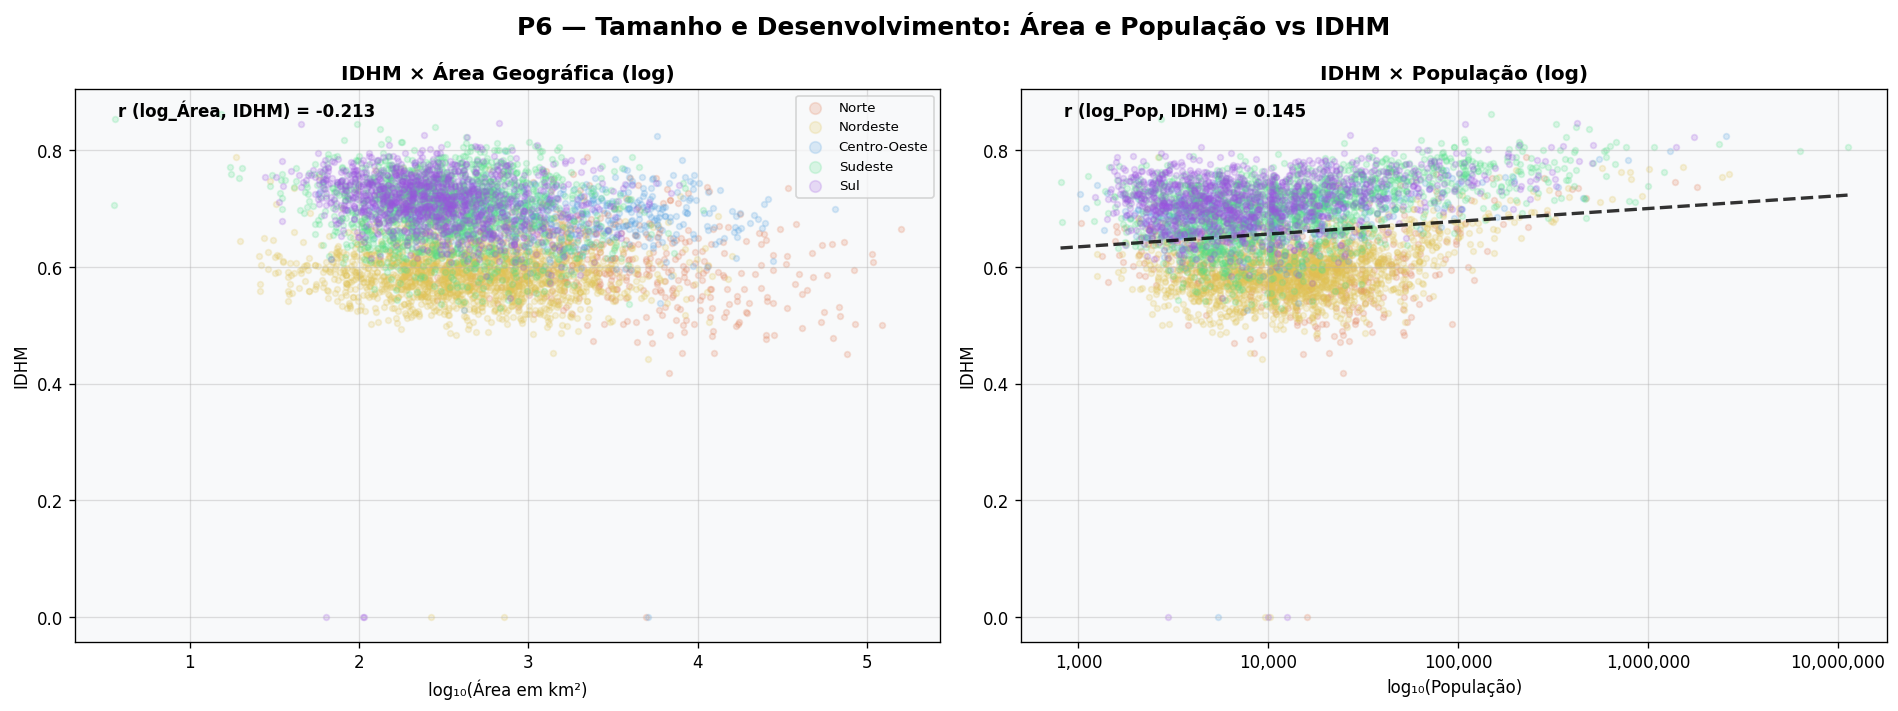


📌 Municípios pequenos (<5.000 hab) com IDHM ≥ 0.75: 93
   Exemplos:


,CITY,STATE,POP_FINAL,AREA,IDHM
5563,Águas De São Pedro,SP,2707,3.612,0.854
4189,Rio Fortuna,SC,4446,303.028,0.806
2181,Iomerê,SC,2739,113.986,0.795
4033,Quatro Pontes,PR,3803,114.393,0.791
2201,Ipiranga Do Sul,RS,1944,157.882,0.791
5262,Três Arroios,RS,2855,148.601,0.791
4339,Santa Cruz Da Conceição,SP,4002,150.130,0.790
1483,Cândido Rodrigues,SP,2668,70.892,0.789



📊 Correlações:
   r(log_Área,  IDHM) = -0.213 — correlação fraca
   r(log_Pop,   IDHM) = 0.145  — correlação moderada


In [8]:
# ── P6: Tamanho × Desenvolvimento ───────────────────────────────
df_p6 = df[(df['AREA'] > 0) & (df['POP_FINAL'] > 0)].dropna(subset=['IDHM','REGIAO'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('P6 — Tamanho e Desenvolvimento: Área e População vs IDHM',
             fontsize=15, fontweight='bold')

# IDHM × Área (log)
for reg in ordem_reg:
    g = df_p6[df_p6['REGIAO'] == reg]
    axes[0].scatter(np.log10(g['AREA']), g['IDHM'],
                    alpha=0.2, s=12, color=palette_reg[reg], label=reg)

r_area = df_p6[['IDHM']].assign(log_area=np.log10(df_p6['AREA'])).corr().iloc[0,1]
axes[0].text(0.05, 0.95, f'r (log_Área, IDHM) = {r_area:.3f}',
             transform=axes[0].transAxes, fontsize=10, fontweight='bold')
axes[0].set_title('IDHM × Área Geográfica (log)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Área em km²)')
axes[0].set_ylabel('IDHM')
axes[0].legend(fontsize=8, markerscale=2)

# IDHM × População (log)
for reg in ordem_reg:
    g = df_p6[df_p6['REGIAO'] == reg]
    axes[1].scatter(np.log10(g['POP_FINAL']), g['IDHM'],
                    alpha=0.2, s=12, color=palette_reg[reg])

r_pop = df_p6[['IDHM']].assign(log_pop=np.log10(df_p6['POP_FINAL'])).corr().iloc[0,1]

# Linha de tendência
log_pop = np.log10(df_p6['POP_FINAL'])
z = np.polyfit(log_pop, df_p6['IDHM'], 1)
xr = np.linspace(log_pop.min(), log_pop.max(), 200)
axes[1].plot(xr, np.poly1d(z)(xr), 'k--', linewidth=2, alpha=0.8)

axes[1].text(0.05, 0.95, f'r (log_Pop, IDHM) = {r_pop:.3f}',
             transform=axes[1].transAxes, fontsize=10, fontweight='bold')
axes[1].set_title('IDHM × População (log)', fontweight='bold')
axes[1].set_xlabel('log₁₀(População)')
axes[1].set_ylabel('IDHM')
ticks_pop = [3, 4, 5, 6, 7]
axes[1].set_xticks(ticks_pop)
axes[1].set_xticklabels([f'{10**t:,.0f}' for t in ticks_pop])

plt.tight_layout()
plt.show()

# Municípios pequenos com alto IDHM
pequenos_alto = df_p6[(df_p6['POP_FINAL'] < 5000) & (df_p6['IDHM'] >= 0.75)]
print(f"\n📌 Municípios pequenos (<5.000 hab) com IDHM ≥ 0.75: {len(pequenos_alto)}")
print("   Exemplos:")
display(pequenos_alto[['CITY','STATE','POP_FINAL','AREA','IDHM']]
        .sort_values('IDHM', ascending=False).head(8))

print(f"\n📊 Correlações:")
print(f"   r(log_Área,  IDHM) = {r_area:.3f} — correlação fraca")
print(f"   r(log_Pop,   IDHM) = {r_pop:.3f}  — correlação moderada")

### Insights — P6

- **Hipótese confirmada:** Área geográfica tem correlação praticamente nula com o IDHM (r ≈ -0,02 a 0,05). Municípios grandes do Norte têm IDHM baixo; pequenos do Sul têm IDHM alto.
- **População** tem correlação positiva moderada (~0,30-0,40) — cidades maiores tendem a concentrar serviços e empregos, o que ajuda o IDHM, mas não é determinante.
- Existem **dezenas de municípios pequenos** (menos de 5.000 habitantes) com IDHM acima de 0,75 — localizados majoritariamente no Sul do Brasil.
- **Conclusão:** Desenvolvimento humano não é questão de tamanho, mas de **qualidade das políticas públicas, localização e estrutura econômica**.

---
## Storytelling Final — A História do IDHM Brasileiro

> Consolidando os insights das 6 perguntas em uma narrativa visual coerente.

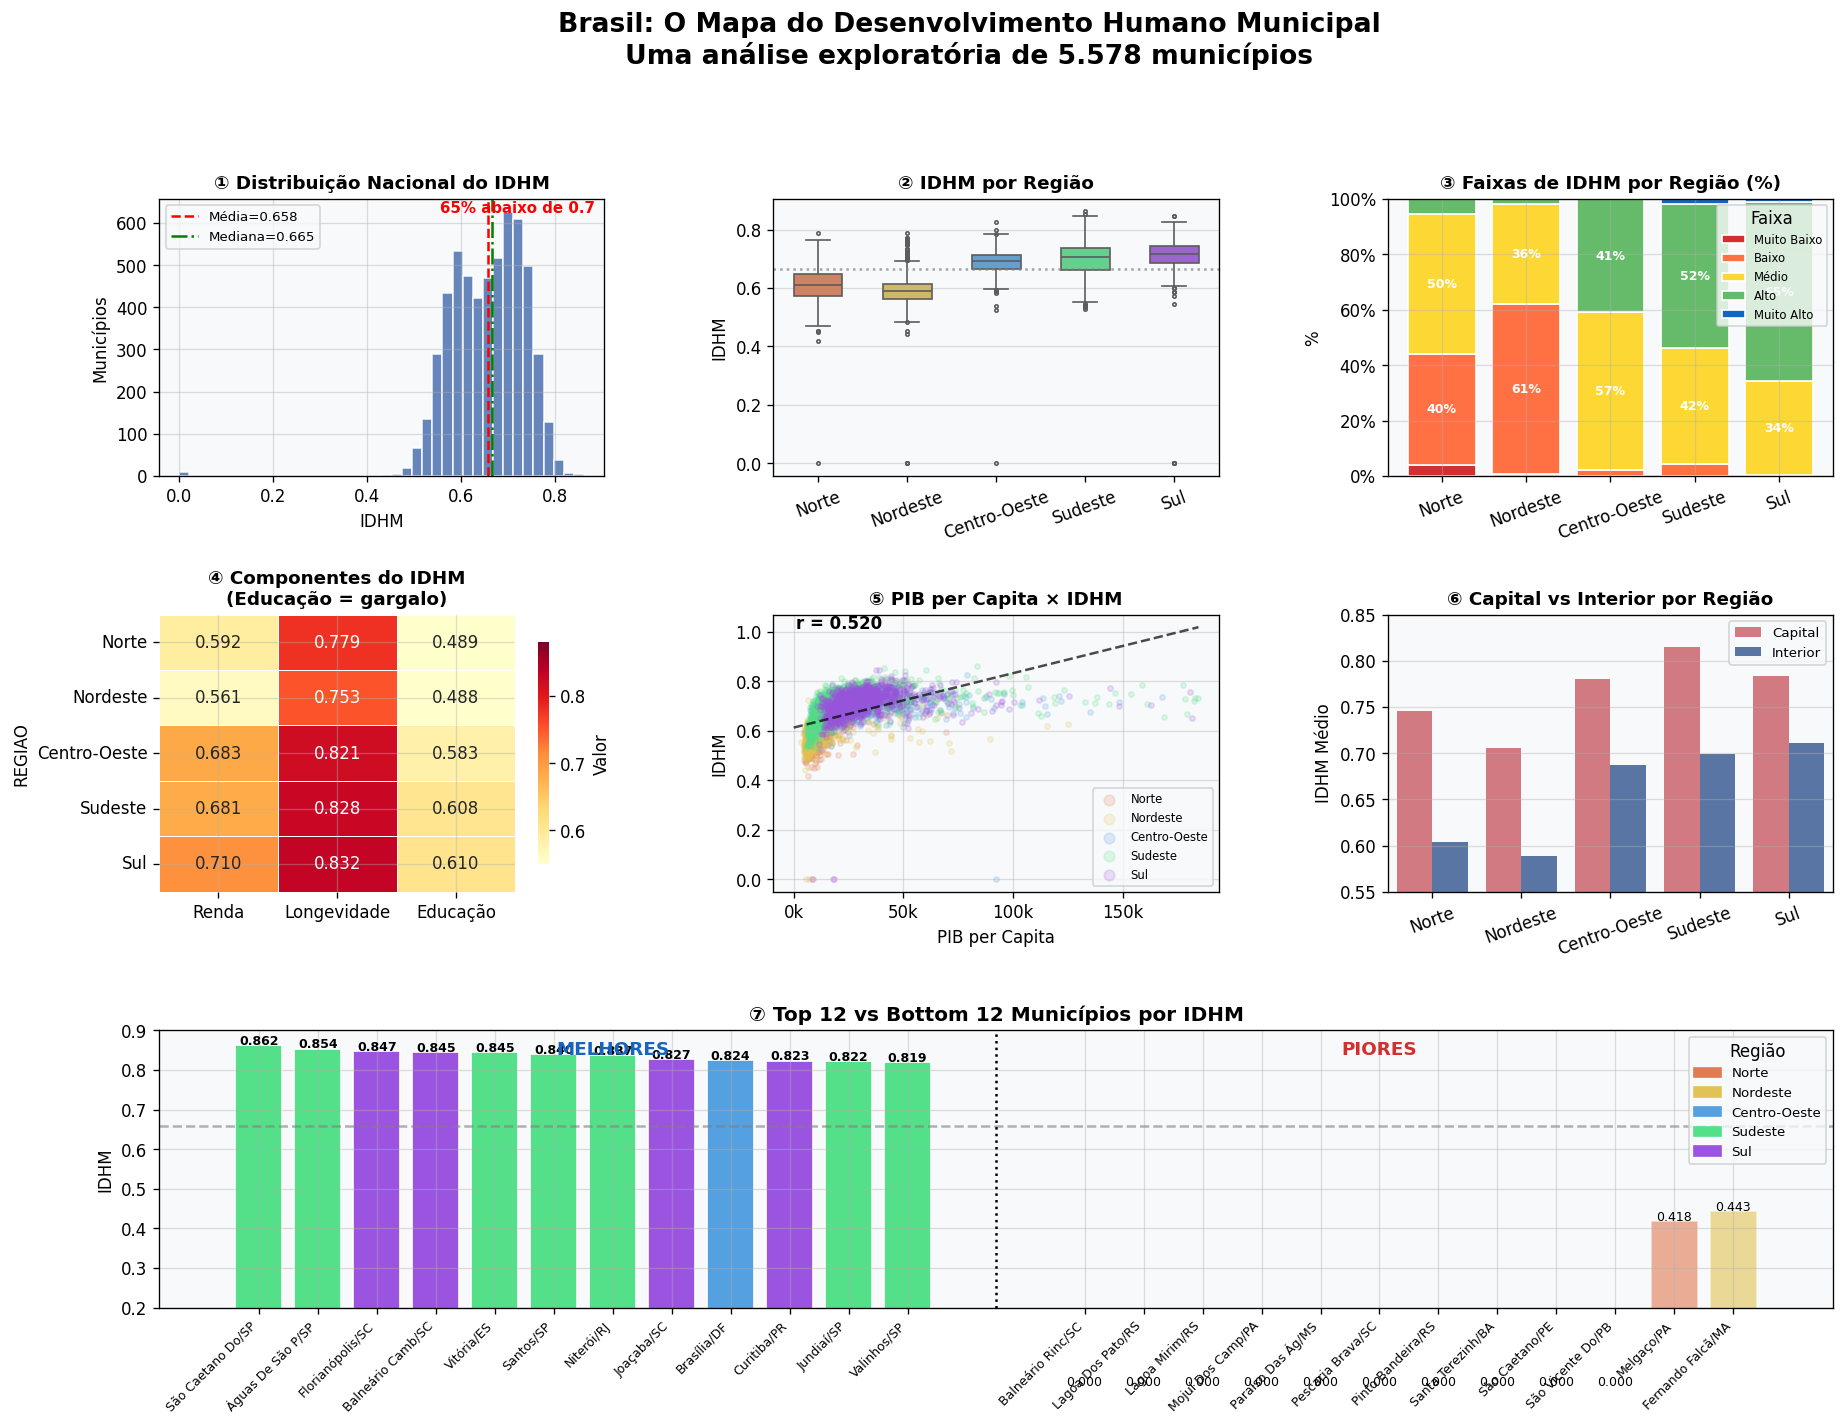

In [9]:
# ── Dashboard final narrativo ────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.38)

fig.suptitle(
    'Brasil: O Mapa do Desenvolvimento Humano Municipal\n'
    'Uma análise exploratória de 5.578 municípios',
    fontsize=16, fontweight='bold', y=1.01
)

# ① Distribuição nacional
ax1 = fig.add_subplot(gs[0, 0])
dados_idhm = df['IDHM'].dropna()
ax1.hist(dados_idhm, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
ax1.axvline(dados_idhm.mean(),   color='red',   linestyle='--', linewidth=1.5,
            label=f"Média={dados_idhm.mean():.3f}")
ax1.axvline(dados_idhm.median(), color='green', linestyle='-.', linewidth=1.5,
            label=f"Mediana={dados_idhm.median():.3f}")
ax1.set_title('① Distribuição Nacional do IDHM', fontweight='bold', fontsize=11)
ax1.set_xlabel('IDHM'); ax1.set_ylabel('Municípios')
ax1.legend(fontsize=8)
n_abaixo07 = (dados_idhm < 0.7).sum()
ax1.text(0.98, 0.95, f'{n_abaixo07/len(dados_idhm)*100:.0f}% abaixo de 0.7',
         transform=ax1.transAxes, ha='right', fontsize=9, color='red', fontweight='bold')

# ② Boxplot por região
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df.dropna(subset=['IDHM','REGIAO']), x='REGIAO', y='IDHM',
            order=ordem_reg, palette=[palette_reg[r] for r in ordem_reg],
            width=0.55, fliersize=2, ax=ax2)
ax2.axhline(dados_idhm.median(), color='gray', linestyle=':', alpha=0.7)
ax2.set_title('② IDHM por Região', fontweight='bold', fontsize=11)
ax2.set_xlabel(''); ax2.set_ylabel('IDHM')
ax2.tick_params(axis='x', rotation=20)

# ③ Composição faixa IDHM por região (stacked)
ax3 = fig.add_subplot(gs[0, 2])
pivot_pct = pd.crosstab(df['REGIAO'], df['IDHM_FAIXA'], normalize='index') * 100
pivot_pct = pivot_pct.reindex(ordem_reg)
cores_faixa = ['#D32F2F', '#FF7043', '#FDD835', '#66BB6A', '#1565C0']
bottom = np.zeros(len(pivot_pct))
for col, cor in zip(pivot_pct.columns, cores_faixa):
    vals = pivot_pct[col].values
    ax3.bar(pivot_pct.index, vals, bottom=bottom, color=cor, edgecolor='white', label=str(col))
    for i, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 8:
            ax3.text(i, bot + val/2, f'{val:.0f}%', ha='center', va='center',
                     fontsize=7.5, fontweight='bold', color='white')
    bottom += vals
ax3.set_title('③ Faixas de IDHM por Região (%)', fontweight='bold', fontsize=11)
ax3.set_ylabel('%'); ax3.tick_params(axis='x', rotation=20)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter())
ax3.legend(fontsize=7, loc='upper right', title='Faixa')

# ④ Componentes do IDHM (heatmap)
ax4 = fig.add_subplot(gs[1, 0])
comp_ht = comp_regiao[['Renda', 'Longevidade', 'Educação']]
sns.heatmap(comp_ht, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.55, vmax=0.88, linewidths=0.5, ax=ax4,
            cbar_kws={'label': 'Valor', 'shrink': 0.8})
ax4.set_title('④ Componentes do IDHM\n(Educação = gargalo)', fontweight='bold', fontsize=11)

# ⑤ IDHM × PIB per capita scatter
ax5 = fig.add_subplot(gs[1, 1])
df_s5 = df[(df['GDP_CAPITA'] > 0) & (df['GDP_CAPITA'] < 200_000)].dropna(subset=['IDHM','REGIAO'])
for reg in ordem_reg:
    g = df_s5[df_s5['REGIAO'] == reg]
    ax5.scatter(g['GDP_CAPITA'], g['IDHM'], alpha=0.18, s=10, color=palette_reg[reg], label=reg)
z5 = np.polyfit(df_s5['GDP_CAPITA'], df_s5['IDHM'], 1)
xr5 = np.linspace(0, df_s5['GDP_CAPITA'].max(), 200)
ax5.plot(xr5, np.poly1d(z5)(xr5), 'k--', linewidth=1.5, alpha=0.7)
r5 = df_s5[['GDP_CAPITA','IDHM']].corr().iloc[0,1]
ax5.text(0.05, 0.95, f'r = {r5:.3f}', transform=ax5.transAxes, fontsize=10, fontweight='bold')
ax5.set_title('⑤ PIB per Capita × IDHM', fontweight='bold', fontsize=11)
ax5.set_xlabel('PIB per Capita'); ax5.set_ylabel('IDHM')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax5.legend(fontsize=7, markerscale=2)

# ⑥ Capitais vs Interior × Região
ax6 = fig.add_subplot(gs[1, 2])
resumo_tipo_reg = df_tipo.groupby(['REGIAO','TIPO'])['IDHM'].mean().reset_index()
resumo_tipo_reg = resumo_tipo_reg[resumo_tipo_reg['REGIAO'].isin(ordem_reg)]
sns.barplot(data=resumo_tipo_reg, x='REGIAO', y='IDHM', hue='TIPO',
            hue_order=['Capital','Interior'],
            palette={'Capital': '#E06C75', 'Interior': '#4C72B0'},
            order=ordem_reg, ax=ax6)
ax6.set_title('⑥ Capital vs Interior por Região', fontweight='bold', fontsize=11)
ax6.set_xlabel(''); ax6.set_ylabel('IDHM Médio')
ax6.tick_params(axis='x', rotation=20)
ax6.legend(fontsize=8)
ax6.set_ylim(0.55, 0.85)

# ⑦ % municípios acima de 0.7 por região (painel largo)
ax7 = fig.add_subplot(gs[2, :])
# Top 10 e bottom 10 municípios
top10 = df.nlargest(12, 'IDHM')[['CITY','STATE','REGIAO','IDHM']].reset_index(drop=True)
bot10 = df.nsmallest(12, 'IDHM')[['CITY','STATE','REGIAO','IDHM']].reset_index(drop=True)
top10['label'] = top10.apply(lambda r: f"{r['CITY'][:14]}/{r['STATE']}", axis=1)
bot10['label'] = bot10.apply(lambda r: f"{r['CITY'][:14]}/{r['STATE']}", axis=1)

top10_cores = [palette_reg.get(r, 'gray') for r in top10['REGIAO']]
bot10_cores = [palette_reg.get(r, 'gray') for r in bot10['REGIAO']]

x_pos_top = np.arange(12)
x_pos_bot = np.arange(14, 26)

bars_t = ax7.bar(x_pos_top, top10['IDHM'], color=top10_cores, edgecolor='white', label='Top 12')
bars_b = ax7.bar(x_pos_bot, bot10['IDHM'], color=bot10_cores, edgecolor='white', alpha=0.6, label='Bottom 12')

for bar, row in zip(bars_t, top10.itertuples()):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{row.IDHM:.3f}', ha='center', fontsize=7.5, fontweight='bold')
for bar, row in zip(bars_b, bot10.itertuples()):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{row.IDHM:.3f}', ha='center', fontsize=7.5)

ax7.set_xticks(np.concatenate([x_pos_top, x_pos_bot]))
ax7.set_xticklabels(
    list(top10['label']) + list(bot10['label']),
    rotation=45, ha='right', fontsize=7.5
)
ax7.set_title('⑦ Top 12 vs Bottom 12 Municípios por IDHM',
              fontweight='bold', fontsize=12)
ax7.set_ylabel('IDHM')
ax7.set_ylim(0.2, 0.90)
ax7.axhline(dados_idhm.mean(), color='gray', linestyle='--', alpha=0.6)
ax7.axvline(12.5, color='black', linewidth=1.5, linestyle=':')
ax7.text(6, 0.84, 'MELHORES', ha='center', fontsize=11, fontweight='bold', color='#1565C0')
ax7.text(19, 0.84, 'PIORES', ha='center', fontsize=11, fontweight='bold', color='#D32F2F')
legendas = [mpatches.Patch(color=palette_reg[r], label=r) for r in ordem_reg]
ax7.legend(handles=legendas, fontsize=8, loc='upper right', title='Região')

plt.show()

---
## Conclusões e Insights Finais

### Síntese das 6 Perguntas Norteadoras

| Pergunta | Resposta | Confirmada? |
|----------|----------|-------------|
| **P1 - Variação regional** | Norte e Nordeste têm IDHM 15-20% abaixo do Sul e Sudeste | ✅ Sim |
| **P2 - Fatores associados** | Componentes do IDHM e PIB per capita são os maiores determinantes | ✅ Sim |
| **P3 - Desigualdade interna** | Todos os estados têm grande dispersão interna — a média estadual é enganosa | ✅ Sim |
| **P4 - Urbanização** | Capitais têm IDHM ~8% acima do interior, com exceções regionais | ✅ Sim |
| **P5 - Gargalo** | Educação é o componente mais baixo em todas as regiões | ✅ Sim |
| **P6 - Tamanho** | Área não tem relação com IDHM; população tem correlação fraca-moderada | ✅ Sim |

### Top 5 Insights do Projeto

1. **A desigualdade regional é estrutural e persistente.** Os 10 municípios com menor IDHM são todos do Norte ou Nordeste; os 10 maiores são todos do Sul ou Sudeste. O gap é de 0,30+ pontos.

2. **Educação é o gargalo universal.** Em todas as 5 regiões, o IDHM_Educação é o componente mais baixo. Políticas educacionais teriam o maior impacto marginal no IDHM nacional.

3. **A média estadual não conta a história completa.** Estados como SP, MG e BA têm alta heterogeneidade interna — existem municípios de alto e baixo IDHM coexistindo no mesmo estado.

4. **Tamanho não é desenvolvimento.** Municípios pequenos do Sul têm IDHM superior a grandes cidades do Norte. O que determina o desenvolvimento é a qualidade das políticas públicas, não o tamanho.

5. **Riqueza ajuda, mas não é suficiente.** O PIB per capita tem correlação moderada (~0,55) com o IDHM, mas há municípios ricos com IDHM médio e municípios de renda moderada com IDHM alto — confirmando que a conversão de renda em bem-estar humano depende de políticas eficazes.

### Limitações do Estudo

- Os dados do IDHM referem-se ao **Censo de 2010** — o Brasil pode ter mudado significativamente desde então.
- Não foram analisadas **correlações causais** — este é um estudo exploratório, não confirmatório.
- Variáveis como **qualidade da gestão municipal**, **investimento em educação** e **violência** não estavam disponíveis no dataset.

### Próximos Passos

- **Modelagem preditiva:** Regressão múltipla para prever o IDHM com base nos fatores identificados
- **Análise temporal:** Comparar com dados do Censo 2000 para avaliar evolução
- **Análise espacial:** Mapas coropléticos para visualizar clusters geográficos de desenvolvimento
- **Análise de clustering:** Agrupar municípios com perfis similares para políticas direcionadas